Traffic accidents are influenced by several factors, including weather conditions, road conditions, time of day, and geographical location. Analyzing accident data can help identify patterns and high-risk areas.

In this project, the US Accidents dataset was analyzed using Python to identify patterns in traffic accidents and understand the factors associated with accident occurrences.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
columns_needed = [
    'ID',
    'Severity',
    'Start_Time',
    'Start_Lat',
    'Start_Lng',
    'State',
    'Weather_Condition',
    'Temperature(F)',
    'Humidity(%)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Precipitation(in)',
    'Sunrise_Sunset',
    'Junction',
    'Crossing',
    'Traffic_Signal',
    'Stop',
    'Railway',
    'Bump'
]

In [ ]:
chunks = []

for chunk in pd.read_csv(
    '/content/US_Accidents_March23.csv',
    usecols=columns_needed,
    chunksize=100000
):
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)

In [ ]:
samples = []

for chunk in pd.read_csv(
    '/content/US_Accidents_March23.csv',
    usecols=columns_needed,
    chunksize=100000
):
    sample = chunk.sample(frac=0.05, random_state=42)
    samples.append(sample)

df = pd.concat(samples, ignore_index=True)

print("Sample size:", df.shape)

Sample size: (30155, 19)


In [ ]:
df.head()

,ID,Severity,Start_Time,Start_Lat,Start_Lng,State,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph),Precipitation(in),Weather_Condition,Bump,Crossing,Junction,Railway,Stop,Traffic_Signal,Sunrise_Sunset
0,A-75728,2,2016-11-28 16:23:04,34.027828,-118.211700,CA,62.1,53.0,10.0,NaN,NaN,Clear,False,False,False,False,False,False,Day
1,A-80191,3,2016-09-28 12:33:15,33.937790,-117.556152,CA,91.9,26.0,10.0,3.5,NaN,Clear,False,False,False,False,False,False,Day
2,A-19865,3,2016-09-13 20:16:23,38.553600,-121.690643,CA,66.2,52.0,10.0,5.8,NaN,Clear,False,False,False,False,False,False,Night
3,A-76706,3,2016-09-13 10:07:38,33.965294,-117.326668,CA,64.9,61.0,10.0,NaN,NaN,Overcast,False,False,False,False,False,False,Day
4,A-92998,3,2016-08-27 17:56:49,33.872711,-118.284805,CA,72.0,68.0,10.0,9.2,NaN,Clear,False,False,False,False,False,False,Day


In [ ]:
df.shape

(30155, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30155 entries, 0 to 30154
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 30155 non-null  object 
 1   Severity           30155 non-null  int64  
 2   Start_Time         30155 non-null  object 
 3   Start_Lat          30155 non-null  float64
 4   Start_Lng          30155 non-null  float64
 5   State              30155 non-null  object 
 6   Temperature(F)     29665 non-null  float64
 7   Humidity(%)        29621 non-null  float64
 8   Visibility(mi)     29486 non-null  float64
 9   Wind_Speed(mph)    25436 non-null  float64
 10  Precipitation(in)  7018 non-null   float64
 11  Weather_Condition  29499 non-null  object 
 12  Bump               30155 non-null  object 
 13  Crossing           30155 non-null  object 
 14  Junction           30155 non-null  object 
 15  Railway            30155 non-null  object 
 16  Stop               301

In [ ]:
df.columns

Index(['ID', 'Severity', 'Start_Time', 'Start_Lat', 'Start_Lng', 'State',
       'Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Bump', 'Crossing',
       'Junction', 'Railway', 'Stop', 'Traffic_Signal', 'Sunrise_Sunset'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
ID,0
Severity,0
Start_Time,0
Start_Lat,0
Start_Lng,0
State,0
Temperature(F),490
Humidity(%),534
Visibility(mi),669
Wind_Speed(mph),4719


In [ ]:
df['Severity'].value_counts()

,count
Severity,
2,17323
3,11336
1,1450
4,46


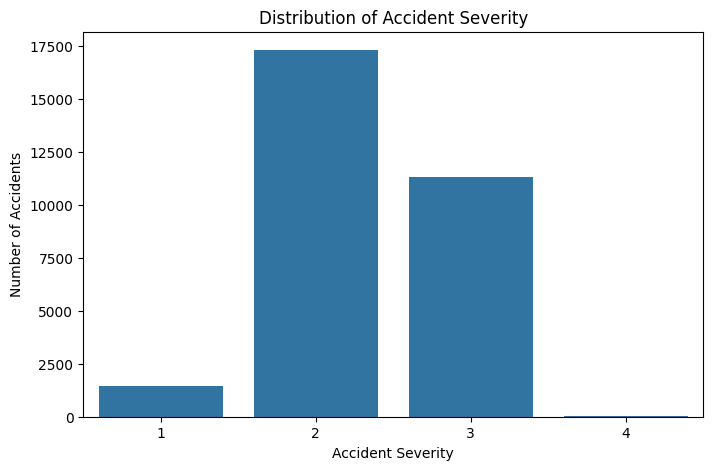

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Severity')

plt.title('Distribution of Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Number of Accidents')

plt.show()

In [ ]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'])

In [ ]:
df['Hour'] = df['Start_Time'].dt.hour

In [ ]:
df[['Start_Time', 'Hour']].head()

,Start_Time,Hour
0,2016-11-28 16:23:04,16
1,2016-09-28 12:33:15,12
2,2016-09-13 20:16:23,20
3,2016-09-13 10:07:38,10
4,2016-08-27 17:56:49,17


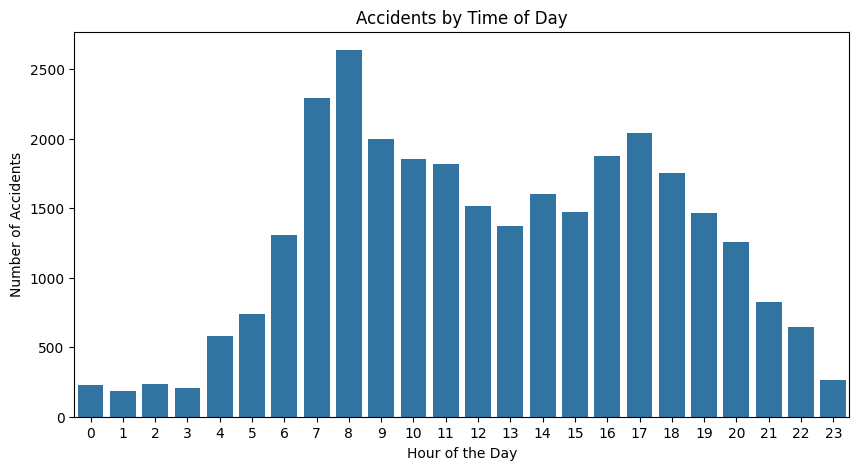

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x='Hour')

plt.title('Accidents by Time of Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Accidents')

plt.show()

In [ ]:
df['Weather_Condition'].value_counts().head(10)

,count
Weather_Condition,
Clear,10379
Mostly Cloudy,4128
Overcast,4010
Partly Cloudy,2974
Fair,2425
Scattered Clouds,2379
Light Rain,1260
Cloudy,469
Haze,321


The analysis shows that most recorded accidents occurred under clear weather conditions, followed by mostly cloudy and overcast conditions. However, this does not mean clear weather causes more accidents, since the dataset records accidents rather than the total number of vehicles traveling under each condition.

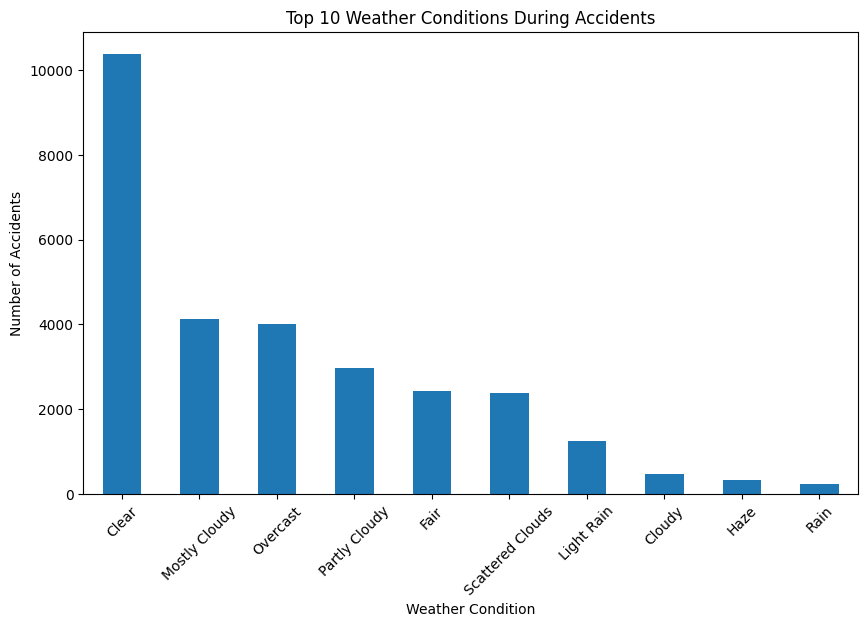

In [ ]:
weather_counts = df['Weather_Condition'].value_counts().head(10)

plt.figure(figsize=(10,6))

weather_counts.plot(kind='bar')

plt.title('Top 10 Weather Conditions During Accidents')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)

plt.show()

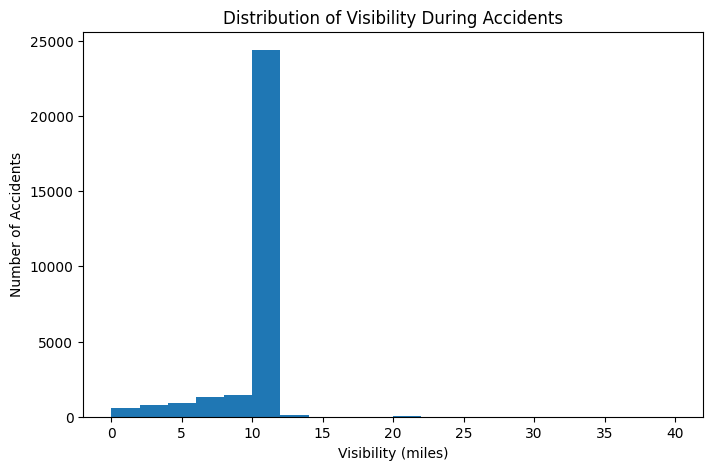

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['Visibility(mi)'].dropna(), bins=20)

plt.title('Distribution of Visibility During Accidents')
plt.xlabel('Visibility (miles)')
plt.ylabel('Number of Accidents')

plt.show()

In [ ]:
road_features = ['Junction', 'Crossing', 'Traffic_Signal', 'Stop', 'Railway', 'Bump']

road_counts = df[road_features].sum()

print(road_counts)

Junction          1882
Crossing          4000
Traffic_Signal    6612
Stop               934
Railway            289
Bump                 7
dtype: object


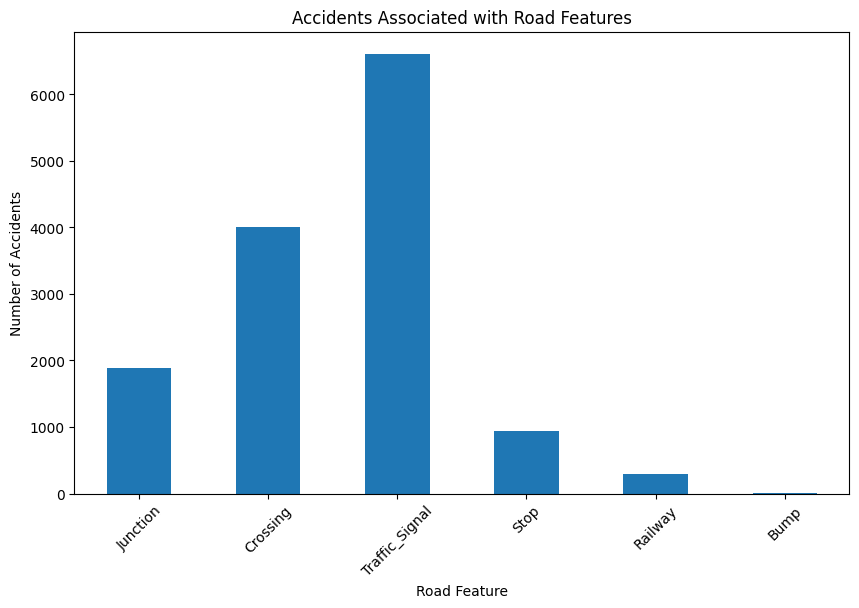

In [ ]:
plt.figure(figsize=(10,6))

road_counts.plot(kind='bar')

plt.title('Accidents Associated with Road Features')
plt.xlabel('Road Feature')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)

plt.show()

In [ ]:
print(road_counts)

Junction          1882
Crossing          4000
Traffic_Signal    6612
Stop               934
Railway            289
Bump                 7
dtype: object


In [ ]:
df['Lat_Rounded'] = df['Start_Lat'].round(2)
df['Lng_Rounded'] = df['Start_Lng'].round(2)

In [ ]:
hotspots = (
    df.groupby(['Lat_Rounded', 'Lng_Rounded'])
      .size()
      .reset_index(name='Accident_Count')
      .sort_values('Accident_Count', ascending=False)
)

hotspots.head(10)

,Lat_Rounded,Lng_Rounded,Accident_Count
5232,33.88,-118.10,34
5473,33.94,-118.10,29
6339,34.16,-118.47,27
5840,34.04,-118.27,26
8353,37.81,-122.37,24
14622,42.48,-83.11,23
3764,32.79,-96.81,23
7760,37.32,-121.94,22
12513,40.85,-73.94,21
4914,33.77,-84.39,21


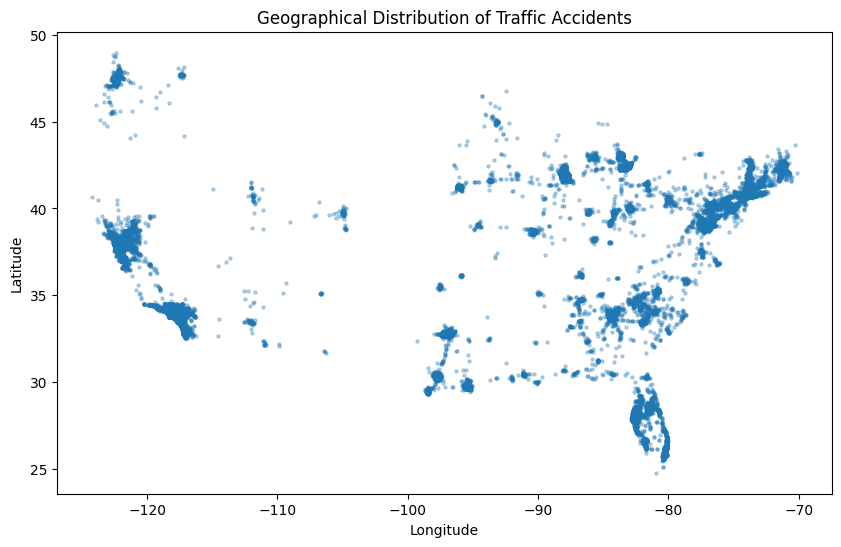

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Start_Lng'],
    df['Start_Lat'],
    s=5,
    alpha=0.3
)

plt.title('Geographical Distribution of Traffic Accidents')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

In [ ]:
state_counts = df['State'].value_counts().head(10)

print(state_counts)

State
CA    9561
TX    4464
FL    2988
PA    1782
NY    1450
MI    1394
GA    1105
IL    1048
WA     696
OH     696
Name: count, dtype: int64


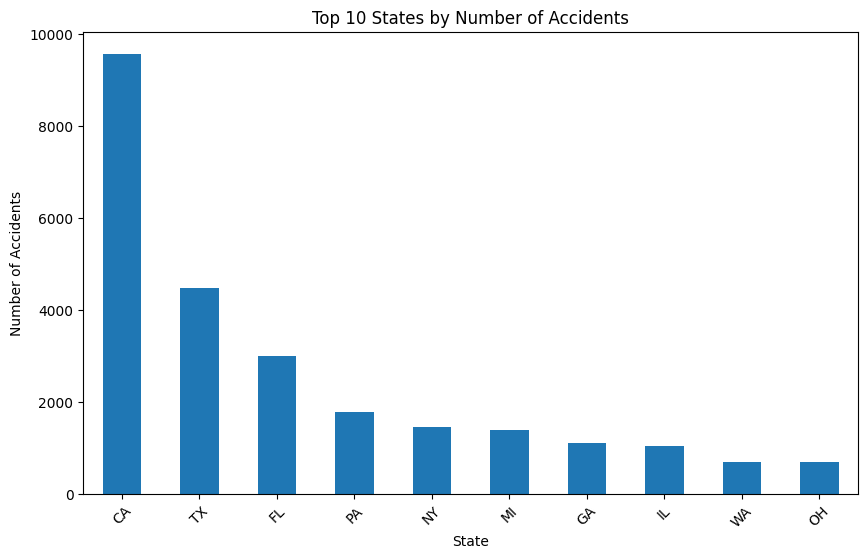

In [ ]:
plt.figure(figsize=(10, 6))

state_counts.plot(kind='bar')

plt.title('Top 10 States by Number of Accidents')
plt.xlabel('State')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)

plt.show()

In [ ]:
hotspots.head(10)

,Lat_Rounded,Lng_Rounded,Accident_Count
5232,33.88,-118.10,34
5473,33.94,-118.10,29
6339,34.16,-118.47,27
5840,34.04,-118.27,26
8353,37.81,-122.37,24
14622,42.48,-83.11,23
3764,32.79,-96.81,23
7760,37.32,-121.94,22
12513,40.85,-73.94,21
4914,33.77,-84.39,21


In [ ]:
state_counts

,count
State,
CA,9561
TX,4464
FL,2988
PA,1782
NY,1450
MI,1394
GA,1105
IL,1048
WA,696


In [ ]:
severity_hour = pd.crosstab(df['Hour'], df['Severity'])

print(severity_hour)

Severity    1     2    3  4
Hour                       
0           2   112  114  0
1           2    78  103  0
2          12   110  114  0
3           7    91  106  2
4         112   261  206  3
5          94   376  268  3
6         164   690  452  3
7         282  1274  732  1
8         294  1509  832  2
9          59  1231  705  1
10         55  1159  632  4
11         38  1135  643  2
12          8   909  601  1
13         19   813  533  5
14         19   958  620  2
15         34   826  608  2
16         55  1075  740  2
17         81  1168  788  4
18         57  1004  688  1
19         39   834  592  2
20          4   750  499  3
21          6   440  379  2
22          4   369  272  1
23          3   151  109  0


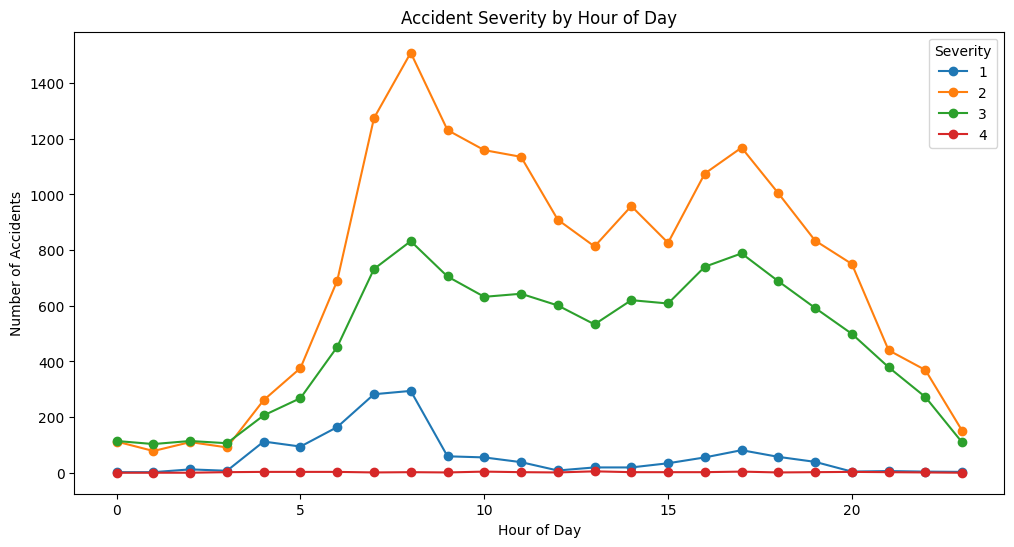

In [ ]:
severity_hour.plot(
    kind='line',
    figsize=(12,6),
    marker='o'
)

plt.title('Accident Severity by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')
plt.legend(title='Severity')

plt.show()

In [ ]:
top_weather = df['Weather_Condition'].value_counts().head(10).index

weather_severity = pd.crosstab(
    df[df['Weather_Condition'].isin(top_weather)]['Weather_Condition'],
    df[df['Weather_Condition'].isin(top_weather)]['Severity']
)

print(weather_severity)

Severity             1     2     3   4
Weather_Condition                     
Clear               10  6646  3721   2
Cloudy             159   144   163   3
Fair               752   848   810  15
Haze                 8   164   149   0
Light Rain          41   680   535   4
Mostly Cloudy      220  2264  1637   7
Overcast             4  2530  1474   2
Partly Cloudy      174  1636  1159   5
Rain                10   116   116   0
Scattered Clouds     2  1463   912   2


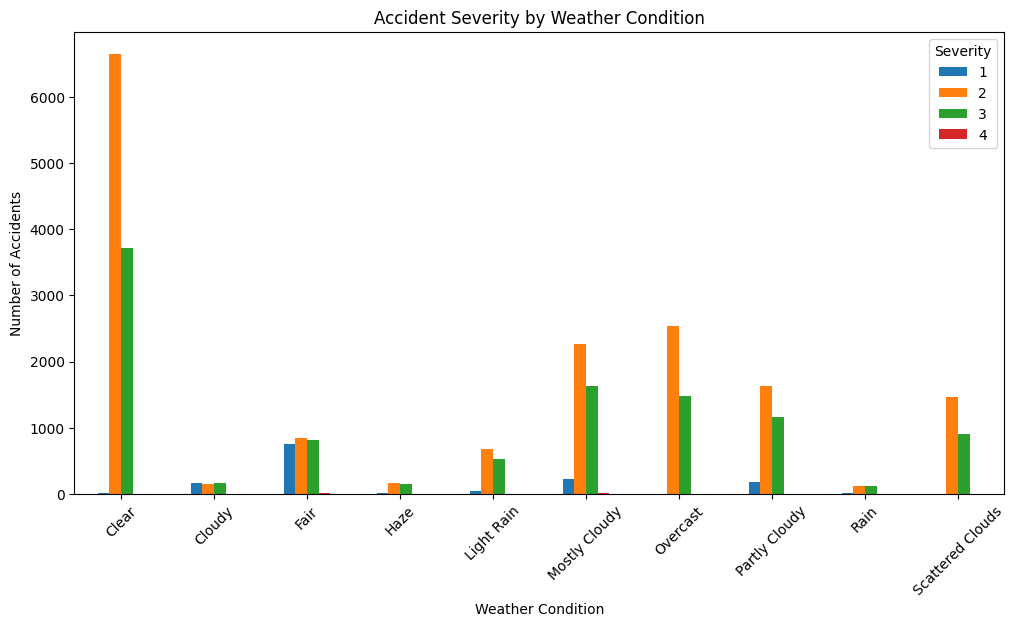

In [ ]:
weather_severity.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Accident Severity by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)

plt.show()

In [ ]:
road_features = [
    'Junction',
    'Crossing',
    'Traffic_Signal',
    'Stop',
    'Railway',
    'Bump'
]

road_counts = df[road_features].sum().sort_values(ascending=False)

print(road_counts)

Traffic_Signal    6612
Crossing          4000
Junction          1882
Stop               934
Railway            289
Bump                 7
dtype: object


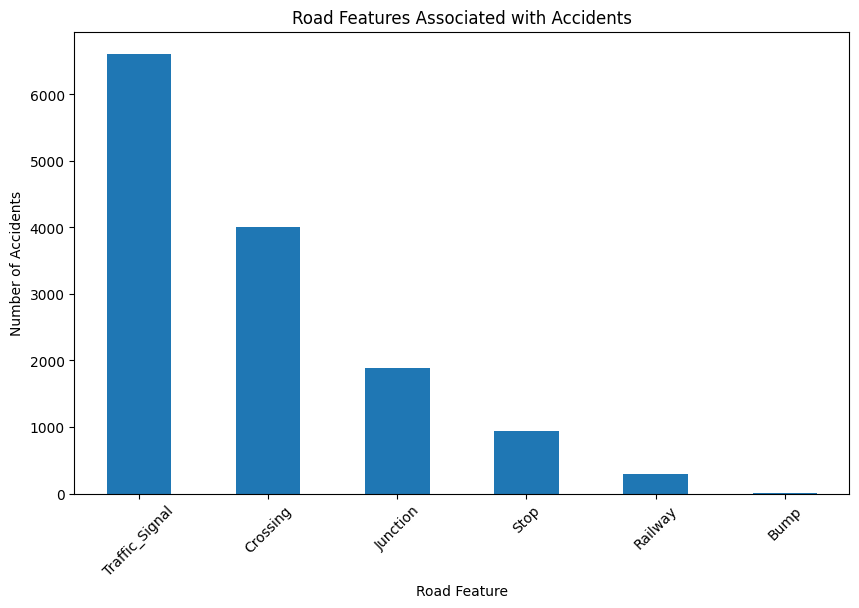

In [ ]:
plt.figure(figsize=(10,6))

road_counts.plot(kind='bar')

plt.title('Road Features Associated with Accidents')
plt.xlabel('Road Feature')
plt.ylabel('Number of Accidents')

plt.xticks(rotation=45)
plt.show()

In [ ]:
hour_counts = df['Hour'].value_counts().sort_index()

print(hour_counts.sort_values(ascending=False).head(10))

Hour
8     2637
7     2289
17    2041
9     1996
16    1872
10    1850
11    1818
18    1750
14    1599
12    1519
Name: count, dtype: int64


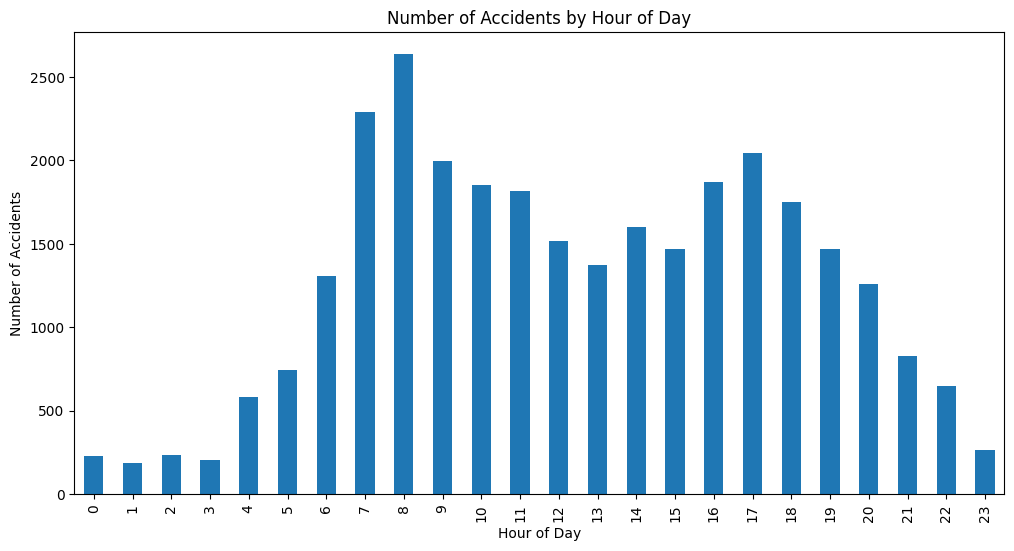

In [ ]:
plt.figure(figsize=(12,6))

hour_counts.plot(kind='bar')

plt.title('Number of Accidents by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')

plt.show()

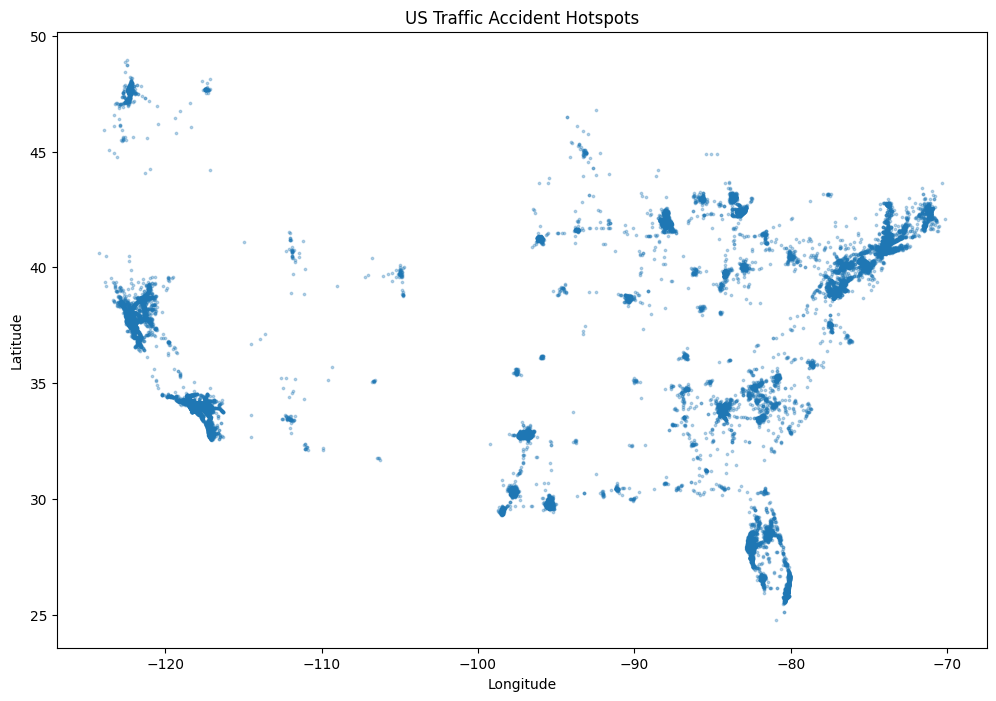

In [ ]:
plt.figure(figsize=(12,8))

plt.scatter(
    df['Start_Lng'],
    df['Start_Lat'],
    s=3,
    alpha=0.3
)

plt.title('US Traffic Accident Hotspots')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

In [ ]:
summary = {
    "Total Accidents Analyzed": len(df),
    "Most Common Weather": df['Weather_Condition'].mode()[0],
    "Most Common Severity": df['Severity'].mode()[0],
    "Peak Accident Hour": df['Hour'].value_counts().idxmax(),
    "Top Accident State": df['State'].value_counts().idxmax()
}

summary

{'Total Accidents Analyzed': 30155,
 'Most Common Weather': 'Clear',
 'Most Common Severity': np.int64(2),
 'Peak Accident Hour': np.int32(8),
 'Top Accident State': 'CA'}

In [ ]:
top_states = df['State'].value_counts().head(5)

print(top_states)

State
CA    9561
TX    4464
FL    2988
PA    1782
NY    1450
Name: count, dtype: int64


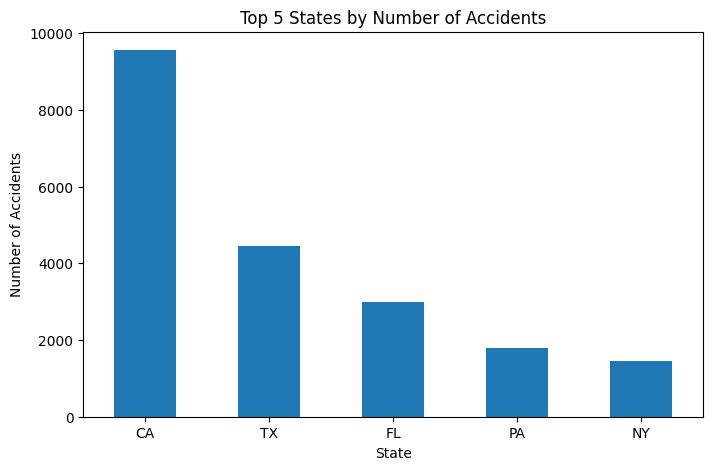

In [ ]:
plt.figure(figsize=(8,5))

top_states.plot(kind='bar')

plt.title('Top 5 States by Number of Accidents')
plt.xlabel('State')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=0)

plt.show()

In [ ]:
top_hours = df['Hour'].value_counts().sort_values(ascending=False).head(5)

print(top_hours)

Hour
8     2637
7     2289
17    2041
9     1996
16    1872
Name: count, dtype: int64


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
ID                       0
Severity                 0
Start_Time               0
Start_Lat                0
Start_Lng                0
State                    0
Temperature(F)         490
Humidity(%)            534
Visibility(mi)         669
Wind_Speed(mph)       4719
Precipitation(in)    23137
Weather_Condition      656
Bump                     0
Crossing                 0
Junction                 0
Railway                  0
Stop                     0
Traffic_Signal           0
Sunrise_Sunset          45
Hour                     0
Lat_Rounded              0
Lng_Rounded              0
dtype: int64


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


 **Conclusion**:The analysis was performed on a representative sample of 30,155 accident records due to computational memory limitations.